# Importarea bibliotecilor

In [116]:
!pip install monai
import os
import shutil
import tempfile
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image

import cv2
import PIL
import torch
import torch.nn as nn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from torchvision.io import read_image
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader
from monai.apps import download_and_extract
from monai.config import print_config
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.networks.nets import DenseNet121
from monai.transforms import (
    Activations,
    EnsureChannelFirst,
    AsDiscrete,
    Compose,
    LoadImage,
    RandFlip,
    RandRotate,
    RandZoom,
    ScaleIntensity,
    Resize
)
from monai.utils import set_determinism

print_config()


MONAI version: 1.4.0
Numpy version: 1.26.4
Pytorch version: 2.5.1+cu121
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 46a5272196a6c2590ca2589029eed8e4d56ff008
MONAI __file__: /usr/local/lib/python3.10/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.5.1
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.2
scikit-image version: 0.25.0
scipy version: 1.13.1
Pillow version: 11.0.0
Tensorboard version: 2.17.1
gdown version: 5.2.0
TorchVision version: 0.20.1+cu121
tqdm version: 4.67.1
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.2.2
einops version: 0.8.0
transformers version: 4.47.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#inst

In [117]:
import kagglehub

path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")

print("Path to dataset files:", path)
from os.path import join

testing_path = join(path, "Testing")
training_path = join(path, "Training")


Path to dataset files: /kaggle/input/brain-tumor-classification-mri


In [118]:
# Setăm variabila de mediu MONAI_DATA_DIRECTORY
os.environ["MONAI_DATA_DIRECTORY"] = "MONAI"

# Verificăm că variabila a fost setată corect
directory = os.environ.get("MONAI_DATA_DIRECTORY")
if directory is not None:
    os.makedirs(directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if directory is None else directory


# Analiza set de date (din laborator)


In [119]:
def analyze_dataset(directory):
    class_names = sorted(x for x in os.listdir(directory) if os.path.isdir(os.path.join(directory, x)))
    num_class = len(class_names)
    image_files = [
        [os.path.join(directory, class_names[i], x) for x in os.listdir(os.path.join(directory, class_names[i]))]
        for i in range(num_class)
    ]
    num_each = [len(image_files[i]) for i in range(num_class)]
    image_files_list = []
    image_class = []
    for i in range(num_class):
        image_files_list.extend(image_files[i])
        image_class.extend([i] * num_each[i])
    num_total = len(image_class)
    image_width, image_height = PIL.Image.open(image_files_list[0]).size

    print(f"Total image count in the dataset: {num_total}")
    print(f"Image dimensions: {image_width} x {image_height}")
    print(f"Label names: {class_names}")
    print(f"Label counts: {num_each}\n")

    return class_names, num_each

analyze_dataset(training_path)
analyze_dataset(testing_path)


Total image count in the dataset: 2870
Image dimensions: 512 x 512
Label names: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Label counts: [826, 822, 395, 827]

Total image count in the dataset: 394
Image dimensions: 200 x 249
Label names: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Label counts: [100, 115, 105, 74]



(['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor'],
 [100, 115, 105, 74])

# Implementarea clasei personalizate

# Split dataset

In [120]:
def split(dataset, test_size=0.2):
    label_indices = {}
    data_enum = enumerate(dataset)

    for i in range(len(dataset)):
        _, label = dataset[i]

        if label not in label_indices:
            label_indices[label] = []

        label_indices[label].append(i)

    train_indices = []
    val_indices = []

    for indices in label_indices.values():
        train_index, val_index = train_test_split(indices, test_size=test_size, random_state=42)
        train_indices.extend(train_index)
        val_indices.extend(val_index)

    train = Subset(dataset, train_indices)
    val = Subset(dataset, val_indices)

    return train, val

In [121]:
class BrainMRIDataset(torch.utils.data.Dataset):
    def __init__(self, root_directory, transforms=None):
        self.samples = []
        self.root_directory = root_directory
        self.transforms = transforms

        for label in os.listdir(root_directory):
            label_directory = os.path.join(root_directory, label)
            for image_file in os.listdir(label_directory):
                self.samples.append((os.path.join(label_directory, image_file), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        image = Image.open(image_path).convert("L")

        if self.transforms:
            return self.transforms(image), label
        return image, label


# Detailed images visualization

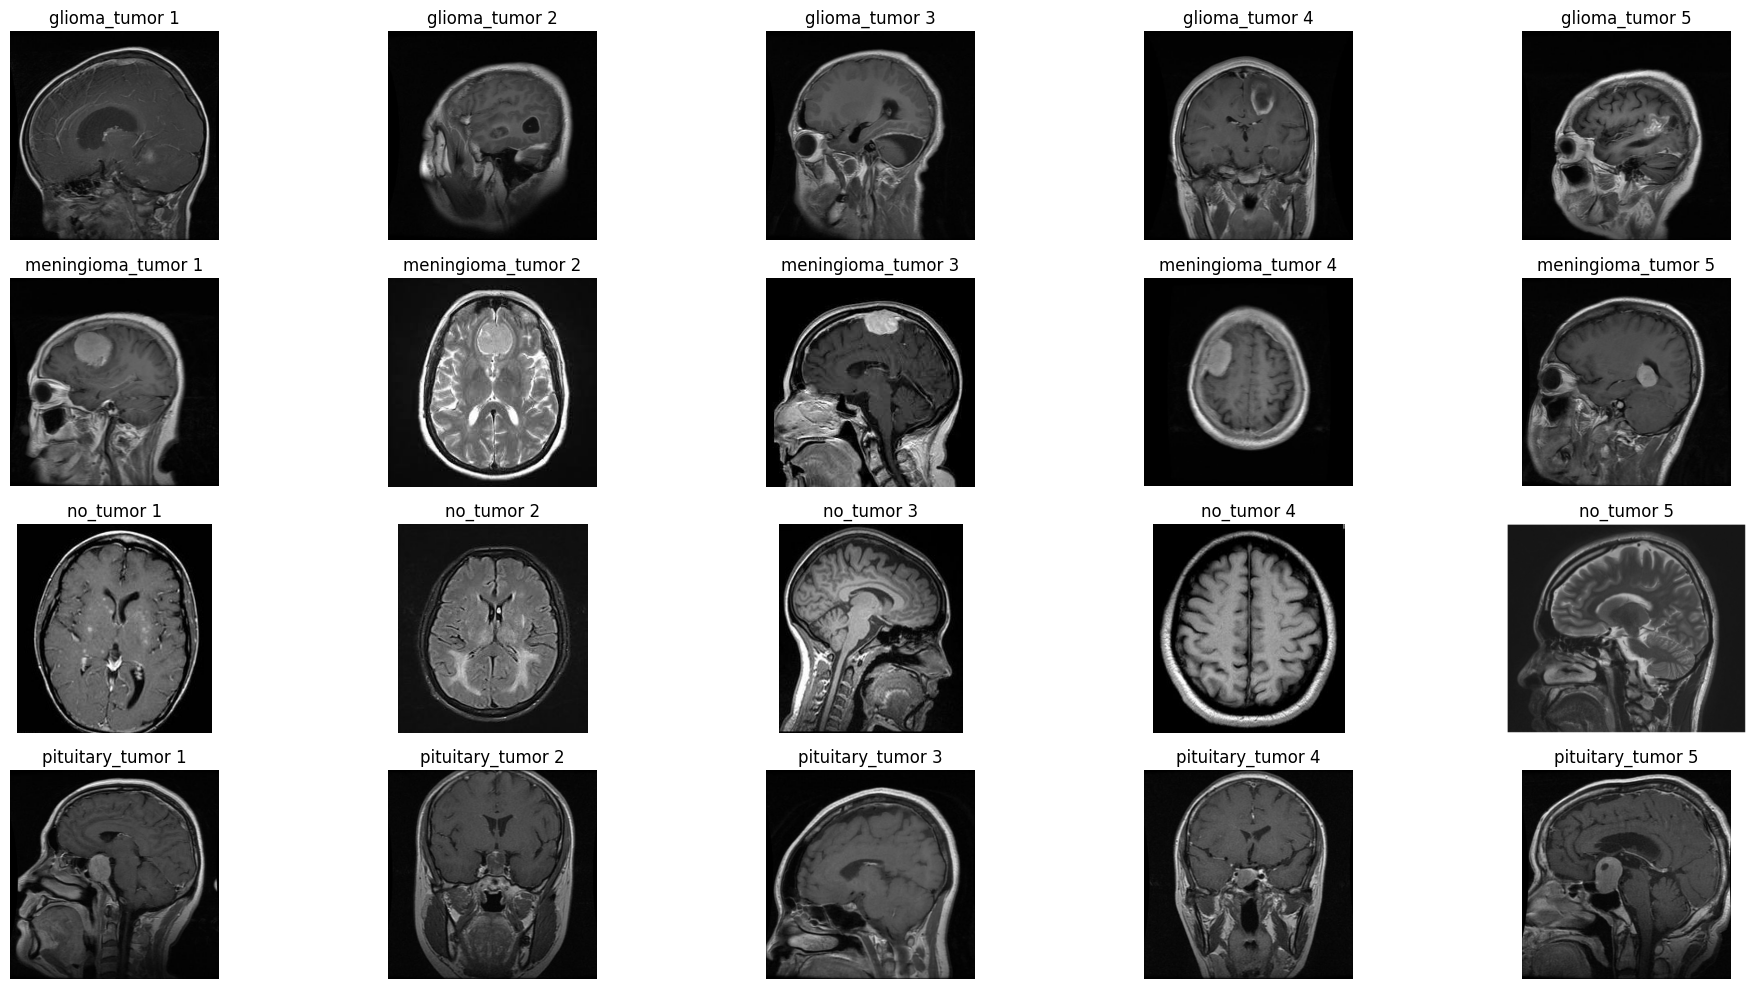

In [122]:
def plot_multiple_img_v2(dataset, images_count=10):
    categories = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

    rows = len(categories)
    fig, axes = plt.subplots(nrows=rows, ncols=images_count, figsize=(20, 10))
    samples = dataset.samples

    for i, category in enumerate(categories):
        category_images = [image for image in samples if category in image[1]]

        displayed_images = random.sample(category_images, images_count)

        for j, (image_path, _) in enumerate(displayed_images):
            image = read_image(image_path)

            ax = axes[i][j]
            ax.imshow(image.permute(1, 2, 0))
            ax.axis('off')
            ax.set_title(f"{category} {j + 1}")

    plt.tight_layout()
    plt.show()

dataset = BrainMRIDataset(root_directory=training_path, transforms=None)
plot_multiple_img_v2(dataset, images_count=5)


# Transformari

In [123]:
def applyGaussian(image, kernel_size=5):
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)

def applyClahe(image):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(image)

def applySobel(image): 
    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    sobel = cv2.magnitude(sobelx, sobely)
    return cv2.convertScaleAbs(sobel)

def applyCanny(image, threshold1=50, threshold2=150):
    return cv2.Canny(image, threshold1, threshold2)

def applyMedianBlur(image, kernel_size=5):
    return cv2.medianBlur(image, kernel_size)

def applyAdaptiveThreshold(image):
    return cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
def flipImage(image):
    return cv2.flip(image, 1)  # Flip orizontal



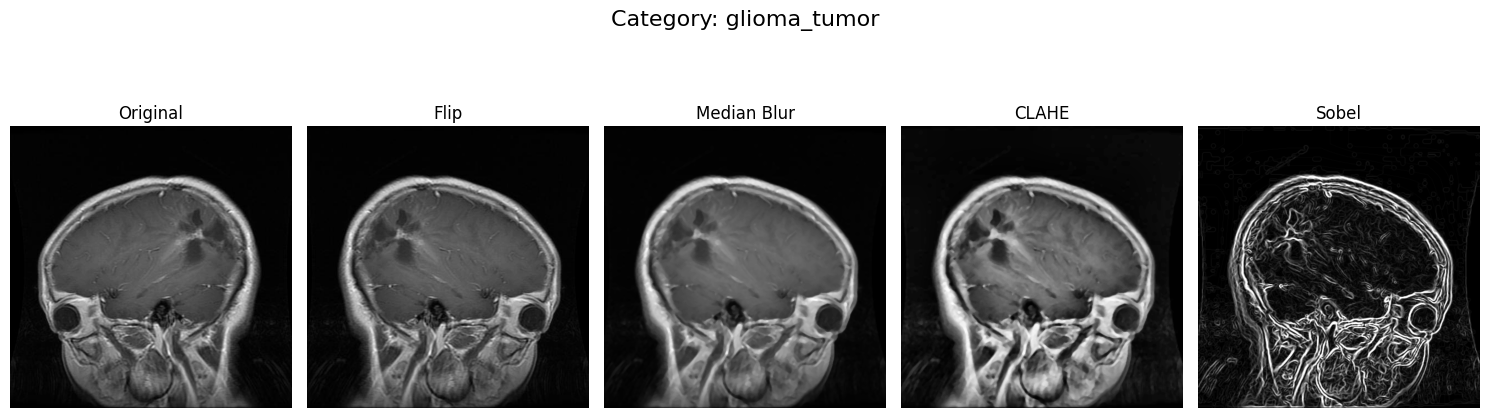

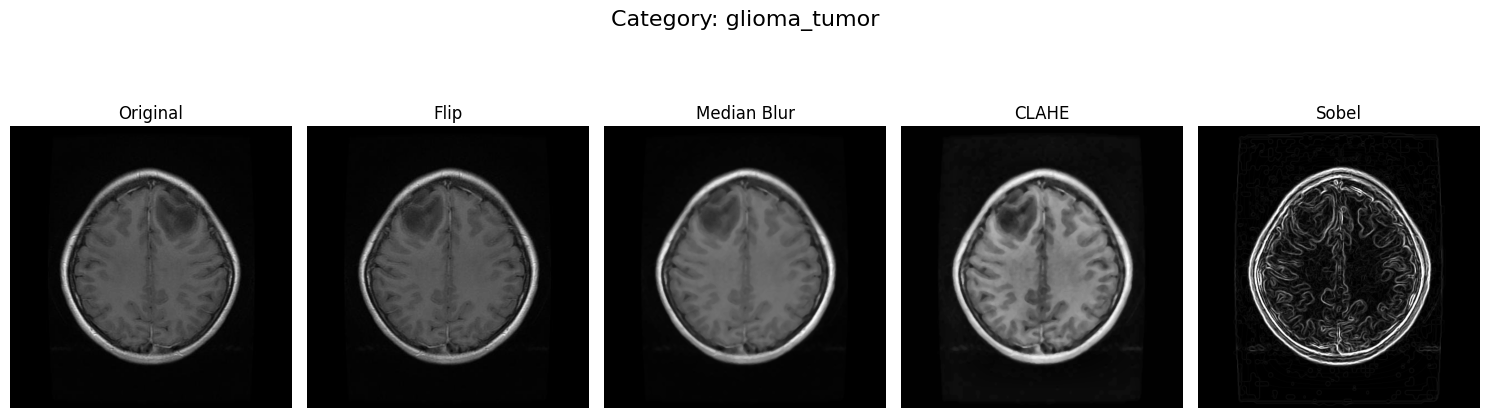

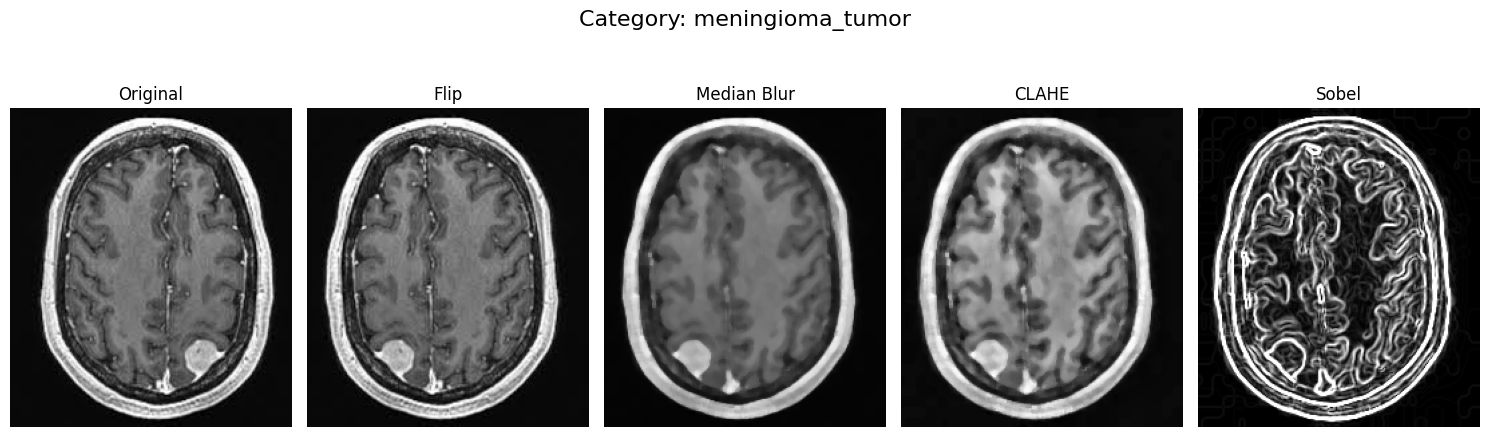

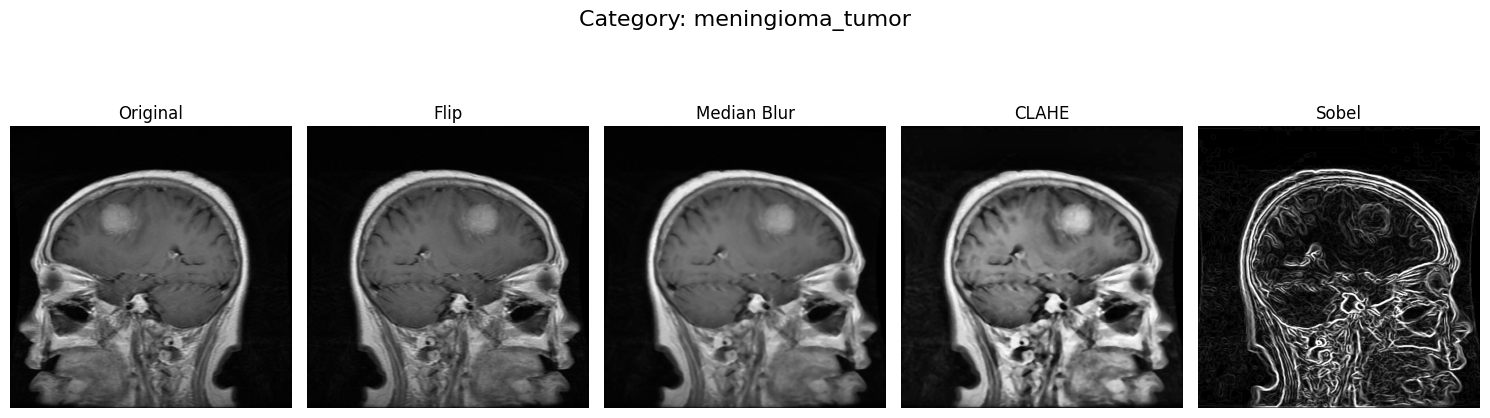

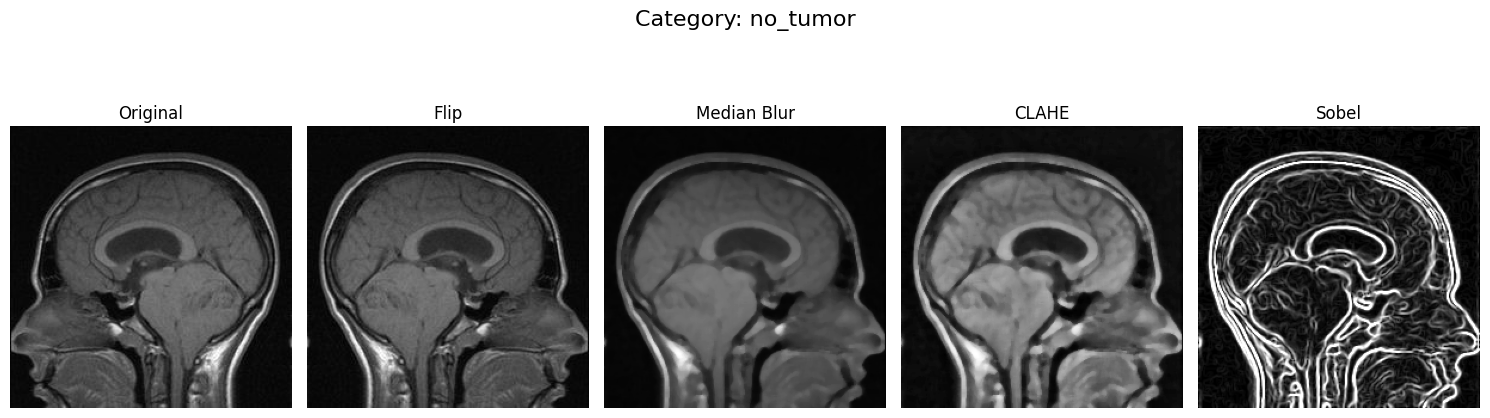

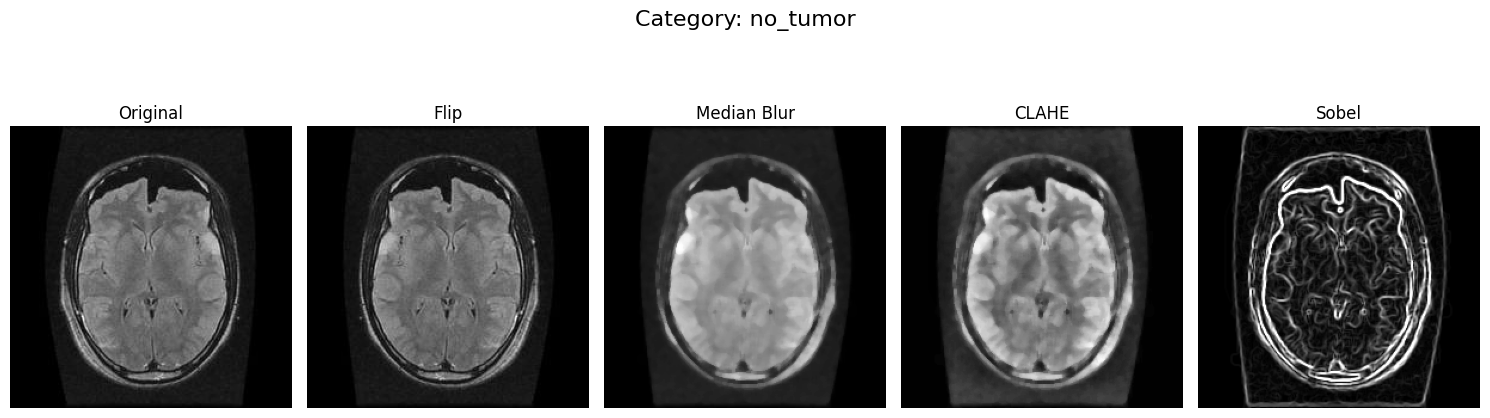

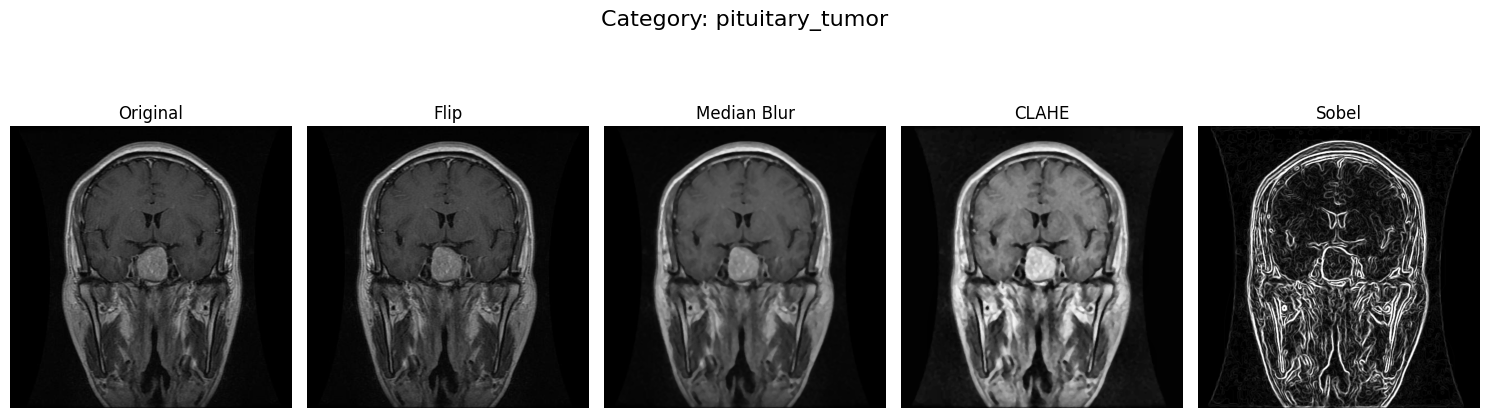

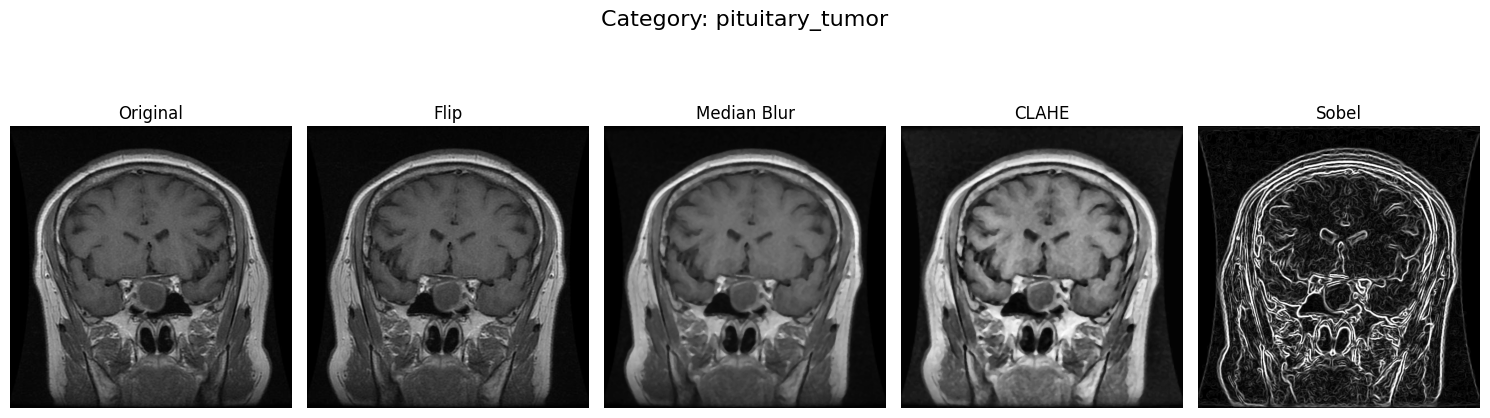

In [124]:
def transformations(images, titles, category):
    num_images = len(images)
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    fig.suptitle(f"Category: {category}", fontsize=16)

    for i, (image, title) in enumerate(zip(images, titles)):
        axes[i].imshow(image, cmap="gray")
        axes[i].axis('off')
        axes[i].set_title(title)

    plt.tight_layout()
    plt.show()

categories = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]
root_directory = training_path

for category in categories:
    category_path = os.path.join(root_directory, category)
    image_paths = [os.path.join(category_path, img) for img in os.listdir(category_path)[:2]]

    images = []
    for image_path in image_paths:
        image = read_image(image_path).numpy()

        if len(image.shape) == 3 and image.shape[0] == 3:
            image = image.transpose(1, 2, 0)
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        images.append(image)

    for image in images:
        original_image = image
        flip_image = flipImage(original_image)
        medianBlur_image = applyMedianBlur(flip_image)
        clahe_image = applyClahe(medianBlur_image)
        sobel_image = applySobel(clahe_image)


        transformations(
            [original_image, flip_image, medianBlur_image, clahe_image, sobel_image],
            ["Original", "Flip", "Median Blur", "CLAHE", "Sobel"],
            category
        )


# Modelul (din laborator)

In [125]:
from torchvision.transforms import ToPILImage, ToTensor, Resize, Normalize
train_transforms = Compose([
    ToTensor(),
    Resize((256, 256)),
    Normalize(mean=[0.485], std=[0.229])
])

In [126]:
class LeNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=4):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 6, kernel_size=5, stride=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)


        self.fc1 = nn.Linear(16 * 61 * 61, 120)  # 16 * 61 *61 * 120 + 120 -> 
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)

        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def name(self):
        return "LeNet"

In [127]:
full_dataset = BrainMRIDataset(root_directory=training_path, transforms=train_transforms)
train_dataset, val_dataset = split(full_dataset)
test_dataset = BrainMRIDataset(root_directory=testing_path, transforms=train_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

# Antrenare model

In [128]:
def reinitialize_model():
    use_cuda = torch.cuda.is_available()
    device = torch.device("cuda" if use_cuda else "cpu")

    model = LeNet(1, 4)
    if use_cuda:
        model.cuda()
    model.to(device)
    
    # optimizer = optim.Adam(model.parameters(), lr=0.01)
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    loss_function = nn.CrossEntropyLoss()

    return model, optimizer, loss_function, device


In [129]:
model, optimizer, loss_function, device = reinitialize_model()
root_directory = "runs"

y_pred_trans = Compose([Activations(softmax=True)])
y_trans = Compose([AsDiscrete(to_onehot=4)])

max_epochs = 6
val_interval = 1
auc_metric = ROCAUCMetric()

best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
val_loss_values = []
metric_values = []
writer = SummaryWriter()

label_to_index = {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}

train_auc_values = []
val_auc_values = []

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    y_pred_train = torch.tensor([], dtype=torch.float32, device=device)
    y_train = torch.tensor([], dtype=torch.long, device=device)

    for (inputs, labels) in train_loader:
        step += 1
        # inputs, labels = batch_data
        labels = [label_to_index[label] for label in labels]

        # if not isinstance(inputs, torch.Tensor):
        #     inputs = torch.stack([torch.tensor(inp, dtype=torch.float32) for inp in inputs])
        if not isinstance(labels, torch.Tensor):
            labels = torch.tensor(labels, dtype=torch.long)
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        # outputs.to(device)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        y_pred_train = torch.cat([y_pred_train, outputs], 0)
        y_train = torch.cat([y_train, labels], 0)

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    y_train_onehot = [y_trans(i) for i in decollate_batch(y_train, detach=False)]
    y_pred_train_act = [y_pred_trans(i) for i in decollate_batch(y_pred_train)]
    auc_metric(y_pred_train_act, y_train_onehot)
    train_auc = auc_metric.aggregate().item()
    auc_metric.reset()
    train_auc_values.append(train_auc)
    print(f"epoch {epoch + 1} training AUC: {train_auc:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        val_loss = 0
        y_pred_val = torch.tensor([], dtype=torch.float32, device=device)
        y_val = torch.tensor([], dtype=torch.long, device=device)
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = val_data
                val_labels = [label_to_index[label] for label in val_labels]

                if not isinstance(val_inputs, torch.Tensor):
                    val_inputs = torch.stack([torch.tensor(inp, dtype=torch.float32) for inp in val_inputs])
                if not isinstance(val_labels, torch.Tensor):
                    val_labels = torch.tensor(val_labels, dtype=torch.long)

                val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
                val_outputs = model(val_inputs)
                val_loss += loss_function(val_outputs, val_labels).item()

                y_pred_val = torch.cat([y_pred_val, val_outputs], 0)
                y_val = torch.cat([y_val, val_labels], 0)

        val_loss /= len(val_loader)
        val_loss_values.append(val_loss)
        print(f"epoch {epoch + 1} validation loss: {val_loss:.4f}")

        y_val_onehot = [y_trans(i) for i in decollate_batch(y_val, detach=False)]
        y_pred_val_act = [y_pred_trans(i) for i in decollate_batch(y_pred_val)]
        auc_metric(y_pred_val_act, y_val_onehot)
        val_auc = auc_metric.aggregate().item()
        auc_metric.reset()
        val_auc_values.append(val_auc)
        print(f"epoch {epoch + 1} validation AUC: {val_auc:.4f}")

        if val_auc > best_metric:
            best_metric = val_auc
            best_metric_epoch = epoch + 1
            torch.save(model.state_dict(), os.path.join(root_dir, "best_metric_model.pth"))
            print("saved new best metric model")

        print(
            f"current epoch: {epoch + 1} current AUC: {val_auc:.4f} "
            f"best AUC: {best_metric:.4f} at epoch: {best_metric_epoch}"
        )



----------
epoch 1/6
epoch 1 average loss: 1.2691
epoch 1 training AUC: 0.6533
epoch 1 validation loss: 0.9134
epoch 1 validation AUC: 0.8407
saved new best metric model
current epoch: 1 current AUC: 0.8407 best AUC: 0.8407 at epoch: 1
----------
epoch 2/6
epoch 2 average loss: 0.8691
epoch 2 training AUC: 0.8567
epoch 2 validation loss: 0.7628
epoch 2 validation AUC: 0.9098
saved new best metric model
current epoch: 2 current AUC: 0.9098 best AUC: 0.9098 at epoch: 2
----------
epoch 3/6
epoch 3 average loss: 0.5877
epoch 3 training AUC: 0.9277
epoch 3 validation loss: 0.5742
epoch 3 validation AUC: 0.9394
saved new best metric model
current epoch: 3 current AUC: 0.9394 best AUC: 0.9394 at epoch: 3
----------
epoch 4/6
epoch 4 average loss: 0.4341
epoch 4 training AUC: 0.9590
epoch 4 validation loss: 0.5467
epoch 4 validation AUC: 0.9409
saved new best metric model
current epoch: 4 current AUC: 0.9409 best AUC: 0.9409 at epoch: 4
----------
epoch 5/6
epoch 5 average loss: 0.2569
epoch 

# Grafice Loss

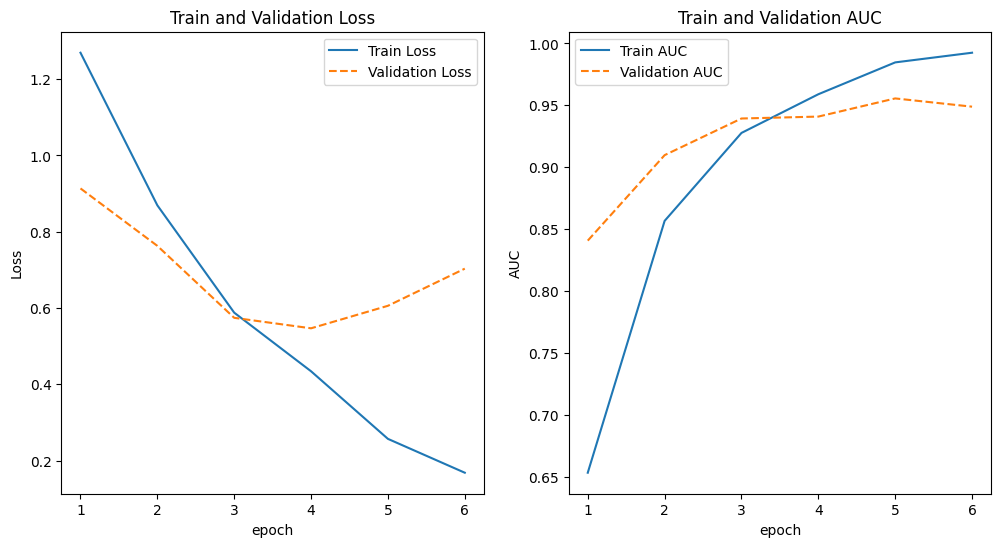

In [130]:
def plot_train_val_metrics(epoch_loss_values, val_loss_values, train_auc_values, val_auc_values):
    plt.figure("Train and Validation Metrics", (12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Train and Validation Loss")
    x = [i + 1 for i in range(len(epoch_loss_values))]
    plt.plot(x, epoch_loss_values, label="Train Loss")
    plt.plot(x, val_loss_values, label="Validation Loss", linestyle="--")
    plt.xlabel("epoch")
    plt.ylabel("Loss")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.title("Train and Validation AUC")
    plt.plot(x, train_auc_values, label="Train AUC")
    plt.plot(x, val_auc_values, label="Validation AUC", linestyle="--")
    plt.xlabel("epoch")
    plt.ylabel("AUC")
    plt.legend()
    
    plt.show()

plot_train_val_metrics(epoch_loss_values, val_loss_values, train_auc_values, val_auc_values)

# Evaluarea pe datasetul de testing

In [131]:
def test_evaluation():
    class_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
    label_to_index = {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
    model.load_state_dict(torch.load(os.path.join(root_dir, "best_metric_model.pth"), weights_only=True))
    model.eval()
    
    y_true = []
    y_pred = []
    
    with torch.no_grad():
      for test_data in test_loader:
        inputs, labels = test_data
        labels = [label_to_index[label] for label in labels]
    
        if not isinstance(inputs, torch.Tensor):
          inputs = torch.stack([torch.tensor(inp, dtype=torch.float32) for inp in inputs])
        if not isinstance(labels, torch.Tensor):
          labels = torch.tensor(labels, dtype=torch.long)
    
        inputs, labels = inputs.to(device), labels.to(device)
        pred = model(inputs).argmax(dim=1)
        for i in range(len(pred)):
          y_true.append(labels[i].item())
          y_pred.append(pred[i].item())
    
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    accuracy = sum([1 if y_true[i] == y_pred[i] else 0 for i in range(len(y_true))]) / len(y_true)
    
    print(f"Precision on test set: {precision:.4f}")
    print(f"Recall on test set: {recall:.4f}")
    print(f"F1-score on test set: {f1:.4f}")
    print(f"Accuracy on test set: {accuracy:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


Precision on test set: 0.6661
Recall on test set: 0.5964
F1-score on test set: 0.5340
Accuracy on test set: 0.5964


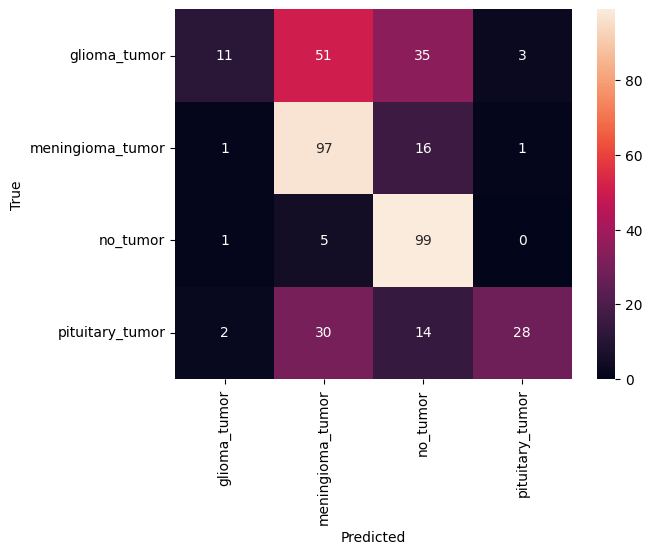

In [132]:
test_evaluation()

# K-fold cross-validation

In [133]:
# Impartirea datelor
def stratified_k_fold_split(dataset, k=5):
    labels = [label for _, label in dataset.samples]
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)  # shuffle=True pentru amestecare aleatorie
    
    folds = []
    for train_index, val_index in skf.split(np.zeros(len(labels)), labels):  # np.zeros folosit ca placeholder pentru date
        folds.append((train_index, val_index))

    return folds

k_folds = stratified_k_fold_split(full_dataset, k=5)

for fold, (train_indices, val_indices) in enumerate(k_folds):
    print(f"Fold {fold + 1}:")
    print(f"  Train size: {len(train_indices)}")
    print(f"  Validation size: {len(val_indices)}")

    train_fold = Subset(full_dataset, train_indices)
    val_fold = Subset(full_dataset, val_indices)


Fold 1:
  Train size: 2296
  Validation size: 574
Fold 2:
  Train size: 2296
  Validation size: 574
Fold 3:
  Train size: 2296
  Validation size: 574
Fold 4:
  Train size: 2296
  Validation size: 574
Fold 5:
  Train size: 2296
  Validation size: 574


Training on Fold 1:
----------
epoch 1/6
epoch 1 average loss: 1.1937
epoch 1 training AUC: 0.6929
epoch 1 validation loss: 0.9470
epoch 1 validation AUC: 0.8365
saved new best metric model
current epoch: 1 current AUC: 0.8365 best AUC: 0.8365 at epoch: 1
----------
epoch 2/6
epoch 2 average loss: 0.7759
epoch 2 training AUC: 0.8760
epoch 2 validation loss: 0.6156
epoch 2 validation AUC: 0.9299
saved new best metric model
current epoch: 2 current AUC: 0.9299 best AUC: 0.9299 at epoch: 2
----------
epoch 3/6
epoch 3 average loss: 0.4878
epoch 3 training AUC: 0.9479
epoch 3 validation loss: 0.5703
epoch 3 validation AUC: 0.9368
saved new best metric model
current epoch: 3 current AUC: 0.9368 best AUC: 0.9368 at epoch: 3
----------
epoch 4/6
epoch 4 average loss: 0.3511
epoch 4 training AUC: 0.9713
epoch 4 validation loss: 0.5229
epoch 4 validation AUC: 0.9469
saved new best metric model
current epoch: 4 current AUC: 0.9469 best AUC: 0.9469 at epoch: 4
----------
epoch 5/6
epoch 5 average

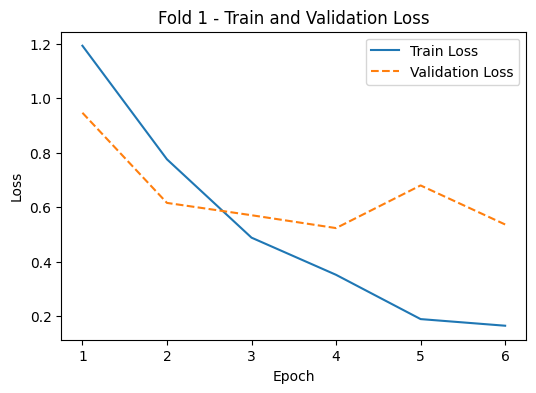

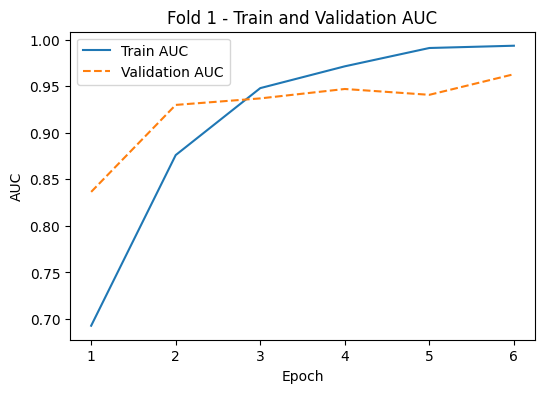

Evaluating on Fold 1:
Fold 1 - Accuracy: 0.8589, Precision: 0.8638, Recall: 0.8589, F1-Score: 0.8585
Training on Fold 2:
----------
epoch 1/6
epoch 1 average loss: 1.1975
epoch 1 training AUC: 0.6937
epoch 1 validation loss: 1.0092
epoch 1 validation AUC: 0.8460
saved new best metric model
current epoch: 1 current AUC: 0.8460 best AUC: 0.8460 at epoch: 1
----------
epoch 2/6
epoch 2 average loss: 0.7999
epoch 2 training AUC: 0.8678
epoch 2 validation loss: 0.6471
epoch 2 validation AUC: 0.9170
saved new best metric model
current epoch: 2 current AUC: 0.9170 best AUC: 0.9170 at epoch: 2
----------
epoch 3/6
epoch 3 average loss: 0.5423
epoch 3 training AUC: 0.9325
epoch 3 validation loss: 0.6014
epoch 3 validation AUC: 0.9306
saved new best metric model
current epoch: 3 current AUC: 0.9306 best AUC: 0.9306 at epoch: 3
----------
epoch 4/6
epoch 4 average loss: 0.3799
epoch 4 training AUC: 0.9661
epoch 4 validation loss: 0.6560
epoch 4 validation AUC: 0.9362
saved new best metric model
c

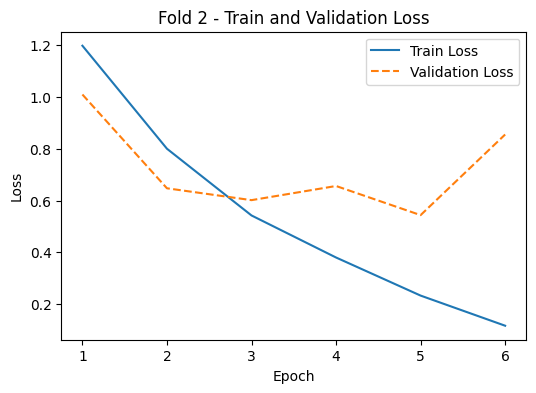

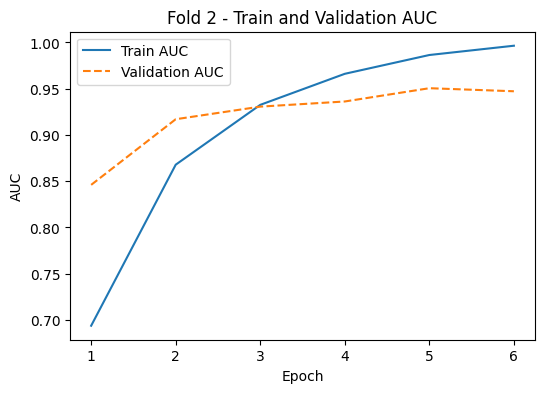

Evaluating on Fold 2:
Fold 2 - Accuracy: 0.8301, Precision: 0.8292, Recall: 0.8301, F1-Score: 0.8293
Training on Fold 3:
----------
epoch 1/6
epoch 1 average loss: 1.1981
epoch 1 training AUC: 0.6965
epoch 1 validation loss: 1.1091
epoch 1 validation AUC: 0.8505
saved new best metric model
current epoch: 1 current AUC: 0.8505 best AUC: 0.8505 at epoch: 1
----------
epoch 2/6
epoch 2 average loss: 0.8226
epoch 2 training AUC: 0.8591
epoch 2 validation loss: 0.7195
epoch 2 validation AUC: 0.9118
saved new best metric model
current epoch: 2 current AUC: 0.9118 best AUC: 0.9118 at epoch: 2
----------
epoch 3/6
epoch 3 average loss: 0.5941
epoch 3 training AUC: 0.9213
epoch 3 validation loss: 0.5640
epoch 3 validation AUC: 0.9378
saved new best metric model
current epoch: 3 current AUC: 0.9378 best AUC: 0.9378 at epoch: 3
----------
epoch 4/6
epoch 4 average loss: 0.4801
epoch 4 training AUC: 0.9505
epoch 4 validation loss: 0.5115
epoch 4 validation AUC: 0.9516
saved new best metric model
c

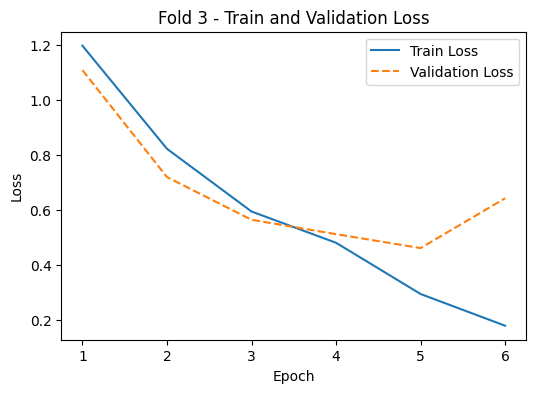

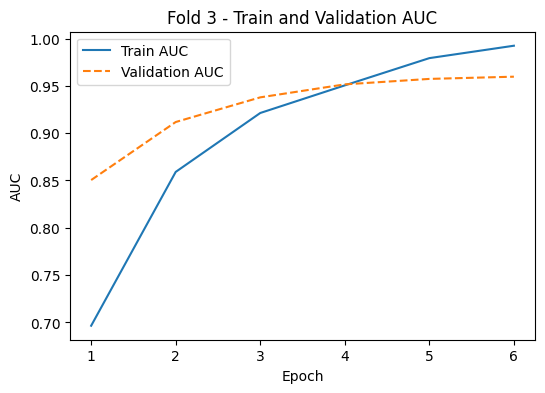

Evaluating on Fold 3:
Fold 3 - Accuracy: 0.8368, Precision: 0.8369, Recall: 0.8368, F1-Score: 0.8366
Training on Fold 4:
----------
epoch 1/6
epoch 1 average loss: 1.1862
epoch 1 training AUC: 0.7113
epoch 1 validation loss: 1.3780
epoch 1 validation AUC: 0.8252
saved new best metric model
current epoch: 1 current AUC: 0.8252 best AUC: 0.8252 at epoch: 1
----------
epoch 2/6
epoch 2 average loss: 0.8249
epoch 2 training AUC: 0.8667
epoch 2 validation loss: 0.6420
epoch 2 validation AUC: 0.9127
saved new best metric model
current epoch: 2 current AUC: 0.9127 best AUC: 0.9127 at epoch: 2
----------
epoch 3/6
epoch 3 average loss: 0.5618
epoch 3 training AUC: 0.9319
epoch 3 validation loss: 0.6240
epoch 3 validation AUC: 0.9179
saved new best metric model
current epoch: 3 current AUC: 0.9179 best AUC: 0.9179 at epoch: 3
----------
epoch 4/6
epoch 4 average loss: 0.4086
epoch 4 training AUC: 0.9632
epoch 4 validation loss: 0.5011
epoch 4 validation AUC: 0.9497
saved new best metric model
c

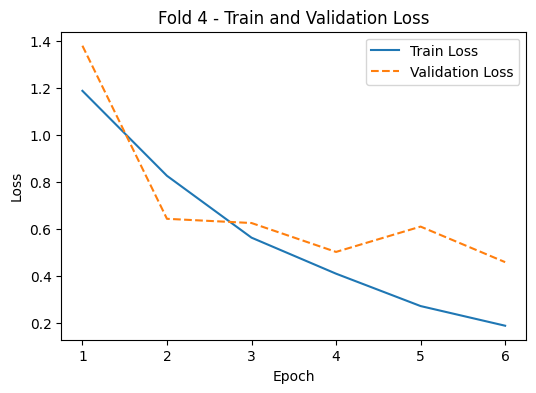

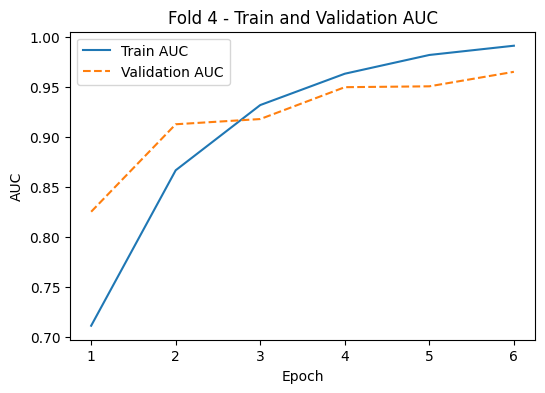

Evaluating on Fold 4:
Fold 4 - Accuracy: 0.8397, Precision: 0.8392, Recall: 0.8397, F1-Score: 0.8392
Training on Fold 5:
----------
epoch 1/6
epoch 1 average loss: 1.2481
epoch 1 training AUC: 0.6932
epoch 1 validation loss: 0.9076
epoch 1 validation AUC: 0.8546
saved new best metric model
current epoch: 1 current AUC: 0.8546 best AUC: 0.8546 at epoch: 1
----------
epoch 2/6
epoch 2 average loss: 0.7903
epoch 2 training AUC: 0.8738
epoch 2 validation loss: 0.6592
epoch 2 validation AUC: 0.9132
saved new best metric model
current epoch: 2 current AUC: 0.9132 best AUC: 0.9132 at epoch: 2
----------
epoch 3/6
epoch 3 average loss: 0.4920
epoch 3 training AUC: 0.9452
epoch 3 validation loss: 0.4620
epoch 3 validation AUC: 0.9550
saved new best metric model
current epoch: 3 current AUC: 0.9550 best AUC: 0.9550 at epoch: 3
----------
epoch 4/6
epoch 4 average loss: 0.3031
epoch 4 training AUC: 0.9783
epoch 4 validation loss: 0.5502
epoch 4 validation AUC: 0.9546
current epoch: 4 current AUC:

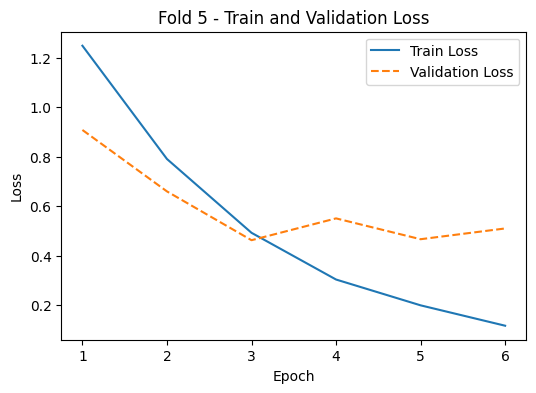

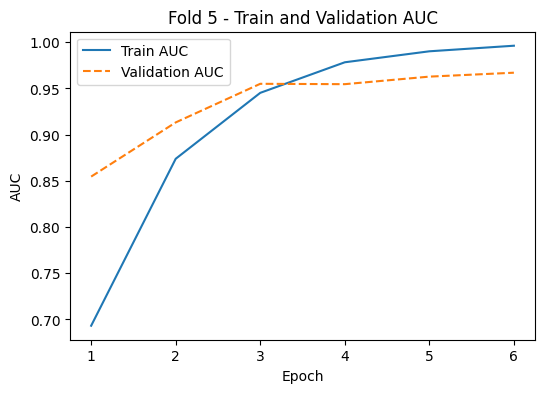

Evaluating on Fold 5:
Fold 5 - Accuracy: 0.8429, Precision: 0.8441, Recall: 0.8429, F1-Score: 0.8428

Average Precision: 0.8426
Average Recall: 0.8417
Average F1-Score: 0.8413
Average Accuracy: 0.8417


In [134]:
# K-fold cross-validation training loop
all_precisions, all_recalls, all_f1s, all_accuracies, all_confusion_matrices = [], [], [], [], []
y_true = []
y_pred = []

for fold, (train_indices, val_indices) in enumerate(k_folds):
    print(f"Training on Fold {fold + 1}:")

    train_fold = Subset(full_dataset, train_indices)
    val_fold = Subset(full_dataset, val_indices)

    train_loader = DataLoader(train_fold, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_fold, batch_size=32, shuffle=True)

    model, optimizer, loss_function, device = reinitialize_model()    
    best_metric = -1
    best_metric_epoch = -1
    epoch_loss_values, val_loss_values = [], []
    train_auc_values, val_auc_values = [], []
    train_acc_values, val_acc_values = [], []

    for epoch in range(max_epochs):
        print("-" * 10)
        print(f"epoch {epoch + 1}/{max_epochs}")
        model.train()
        epoch_loss = 0
        step = 0

        y_pred_train = torch.tensor([], dtype=torch.float32, device=device)
        y_train = torch.tensor([], dtype=torch.long, device=device)

        for batch_data in train_loader:
            step += 1
            inputs, labels = batch_data
            labels = [label_to_index[label] for label in labels]

            if not isinstance(inputs, torch.Tensor):
                inputs = torch.stack([torch.tensor(inp, dtype=torch.float32) for inp in inputs])

            if not isinstance(labels, torch.Tensor):
                labels = torch.tensor(labels, dtype=torch.long)

            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

            y_pred_train = torch.cat([y_pred_train, outputs], 0)
            y_train = torch.cat([y_train, labels], 0)

        epoch_loss /= step
        epoch_loss_values.append(epoch_loss)
        print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

        y_train_onehot = [y_trans(i) for i in decollate_batch(y_train, detach=False)]
        y_pred_train_act = [y_pred_trans(i) for i in decollate_batch(y_pred_train)]
        auc_metric(y_pred_train_act, y_train_onehot)
        train_auc = auc_metric.aggregate().item()
        auc_metric.reset()
        train_auc_values.append(train_auc)
        print(f"epoch {epoch + 1} training AUC: {train_auc:.4f}")

        if (epoch + 1) % val_interval == 0:
            model.eval()
            val_loss = 0
            y_pred_val = torch.tensor([], dtype=torch.float32, device=device)
            y_val = torch.tensor([], dtype=torch.long, device=device)
            with torch.no_grad():
                for val_data in val_loader:
                    val_inputs, val_labels = val_data
                    val_labels = [label_to_index[label] for label in val_labels]

                    if not isinstance(val_inputs, torch.Tensor):
                        val_inputs = torch.stack([torch.tensor(inp, dtype=torch.float32) for inp in val_inputs])
                    if not isinstance(val_labels, torch.Tensor):
                        val_labels = torch.tensor(val_labels, dtype=torch.long)

                    val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
                    val_outputs = model(val_inputs)
                    val_loss += loss_function(val_outputs, val_labels).item()

                    y_pred_val = torch.cat([y_pred_val, val_outputs], 0)
                    y_val = torch.cat([y_val, val_labels], 0)

            val_loss /= len(val_loader)
            val_loss_values.append(val_loss)
            print(f"epoch {epoch + 1} validation loss: {val_loss:.4f}")

            y_val_onehot = [y_trans(i) for i in decollate_batch(y_val, detach=False)]
            y_pred_val_act = [y_pred_trans(i) for i in decollate_batch(y_pred_val)]
            auc_metric(y_pred_val_act, y_val_onehot)
            val_auc = auc_metric.aggregate().item()
            auc_metric.reset()
            val_auc_values.append(val_auc)
            print(f"epoch {epoch + 1} validation AUC: {val_auc:.4f}")

        if val_auc > best_metric:
            best_metric = val_auc
            best_metric_epoch = epoch + 1
            torch.save(model.state_dict(), os.path.join(root_dir, "best_metric_model.pth"))
            print("saved new best metric model")

        print(
            f"current epoch: {epoch + 1} current AUC: {val_auc:.4f} "
            f"best AUC: {best_metric:.4f} at epoch: {best_metric_epoch}"
        )

    x = list(range(1, len(epoch_loss_values) + 1))  # Epocile pentru fold-ul curent

    plt.figure(figsize=(6, 4))
    plt.title(f"Fold {fold + 1} - Train and Validation Loss")
    plt.plot(x, epoch_loss_values, label="Train Loss")
    plt.plot(x, val_loss_values, linestyle="--", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.title(f"Fold {fold + 1} - Train and Validation AUC")
    plt.plot(x, train_auc_values, label="Train AUC")
    plt.plot(x, val_auc_values, linestyle="--", label="Validation AUC")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.legend()
    plt.show()

    print(f"Evaluating on Fold {fold + 1}:")

    model, optimizer, loss_function, device = reinitialize_model()
    model.load_state_dict(torch.load(os.path.join(root_dir, "best_metric_model.pth"), weights_only=True))
    model.eval()

    with torch.no_grad():
        for test_data in val_loader:
            inputs, labels = test_data
            labels = [label_to_index[label] for label in labels]

            if not isinstance(inputs, torch.Tensor):
                inputs = torch.stack([torch.tensor(inp, dtype=torch.float32) for inp in inputs])
            if not isinstance(labels, torch.Tensor):
                labels = torch.tensor(labels, dtype=torch.long)

            inputs, labels = inputs.to(device), labels.to(device)

            pred = model(inputs).argmax(dim=1)

            for i in range(len(pred)):
                y_true.append(labels[i].item())
                y_pred.append(pred[i].item())

    # Calcul precision, recall și alte metrici
    fold_precision = precision_score(y_true, y_pred, average="weighted")
    fold_recall = recall_score(y_true, y_pred, average="weighted")
    fold_f1 = f1_score(y_true, y_pred, average="weighted")
    fold_accuracy = sum([1 if y_true[i] == y_pred[i] else 0 for i in range(len(y_true))]) / len(y_true)

    all_precisions.append(fold_precision)
    all_recalls.append(fold_recall)
    all_f1s.append(fold_f1)
    all_accuracies.append(fold_accuracy)


    print(
        f"Fold {fold + 1} - Accuracy: {fold_accuracy:.4f}, Precision: {fold_precision:.4f}, "
        f"Recall: {fold_recall:.4f}, F1-Score: {fold_f1:.4f}"
    )

# Rezultate medii pe toate fold-urile
print(f"\nAverage Precision: {sum(all_precisions)/len(all_precisions):.4f}")
print(f"Average Recall: {sum(all_recalls)/len(all_recalls):.4f}")
print(f"Average F1-Score: {sum(all_f1s)/len(all_f1s):.4f}")
print(f"Average Accuracy: {sum(all_accuracies)/len(all_accuracies):.4f}")


# Evaluarea pe datasetul de testing

Precision on test set: 0.7438
Recall on test set: 0.6802
F1-score on test set: 0.6307
Accuracy on test set: 0.6802


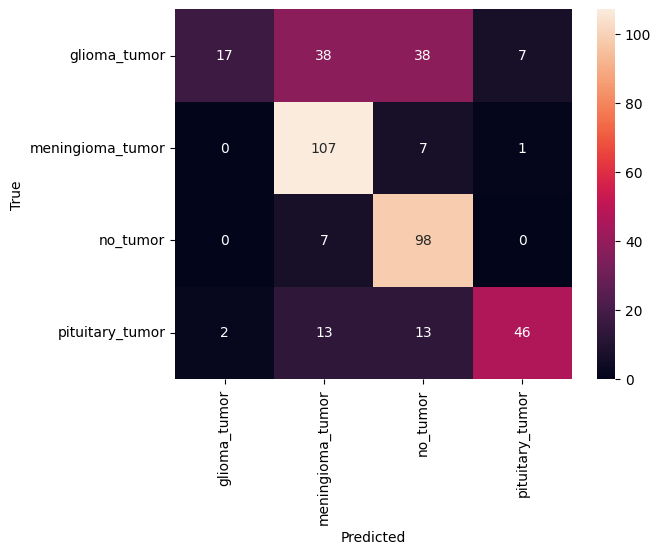

In [135]:
test_evaluation()

# Functia de pierdere cu ponderi

In [136]:
training_label_names, trainig_label_counts = analyze_dataset(training_path)
testing_label_names, testing_label_counts = analyze_dataset(testing_path)


Total image count in the dataset: 2870
Image dimensions: 512 x 512
Label names: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Label counts: [826, 822, 395, 827]

Total image count in the dataset: 394
Image dimensions: 200 x 249
Label names: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Label counts: [100, 115, 105, 74]



In [137]:
def calculate_class_weights(label_counts):
    total_samples = sum(label_counts)
    num_classes = len(label_counts)
    weights = [total_samples / (num_classes * count) for count in label_counts]
    normalized_weights = [w / sum(weights) for w in weights]

    return torch.tensor(normalized_weights, dtype=torch.float32)

training_label_names, training_label_counts = analyze_dataset(training_path)

class_weights = calculate_class_weights(training_label_counts)
print("Class Names:", training_label_names)
print("Class Counts:", training_label_counts)
print("Class Weights:", class_weights)

model, optimizer, loss_function, device = reinitialize_model()
loss_function = nn.CrossEntropyLoss(weight=class_weights.to(device))


Total image count in the dataset: 2870
Image dimensions: 512 x 512
Label names: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Label counts: [826, 822, 395, 827]

Class Names: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Class Counts: [826, 822, 395, 827]
Class Weights: tensor([0.1963, 0.1972, 0.4104, 0.1960])


In [138]:
root_directory = "runs"

y_pred_trans = Compose([Activations(softmax=True)])
y_trans = Compose([AsDiscrete(to_onehot=4)])

max_epochs = 6
val_interval = 1
auc_metric = ROCAUCMetric()

best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
val_loss_values = []
metric_values = []
# writer = SummaryWriter()

label_to_index = {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}

train_auc_values = []
val_auc_values = []

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    y_pred_train = torch.tensor([], dtype=torch.float32, device=device)
    y_train = torch.tensor([], dtype=torch.long, device=device)

    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data
        labels = [label_to_index[label] for label in labels]

        if not isinstance(inputs, torch.Tensor):
            inputs = torch.stack([torch.tensor(inp, dtype=torch.float32) for inp in inputs])
        if not isinstance(labels, torch.Tensor):
            labels = torch.tensor(labels, dtype=torch.long)
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        y_pred_train = torch.cat([y_pred_train, outputs], 0)
        y_train = torch.cat([y_train, labels], 0)

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    y_train_onehot = [y_trans(i) for i in decollate_batch(y_train, detach=False)]
    y_pred_train_act = [y_pred_trans(i) for i in decollate_batch(y_pred_train)]
    auc_metric(y_pred_train_act, y_train_onehot)
    train_auc = auc_metric.aggregate().item()
    auc_metric.reset()
    train_auc_values.append(train_auc)
    print(f"epoch {epoch + 1} training AUC: {train_auc:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        val_loss = 0
        y_pred_val = torch.tensor([], dtype=torch.float32, device=device)
        y_val = torch.tensor([], dtype=torch.long, device=device)
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = val_data
                val_labels = [label_to_index[label] for label in val_labels]

                if not isinstance(val_inputs, torch.Tensor):
                    val_inputs = torch.stack([torch.tensor(inp, dtype=torch.float32) for inp in val_inputs])
                if not isinstance(val_labels, torch.Tensor):
                    val_labels = torch.tensor(val_labels, dtype=torch.long)

                val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
                val_outputs = model(val_inputs)
                val_loss += loss_function(val_outputs, val_labels).item()

                y_pred_val = torch.cat([y_pred_val, val_outputs], 0)
                y_val = torch.cat([y_val, val_labels], 0)

        val_loss /= len(val_loader)
        val_loss_values.append(val_loss)
        print(f"epoch {epoch + 1} validation loss: {val_loss:.4f}")

        y_val_onehot = [y_trans(i) for i in decollate_batch(y_val, detach=False)]
        y_pred_val_act = [y_pred_trans(i) for i in decollate_batch(y_pred_val)]
        auc_metric(y_pred_val_act, y_val_onehot)
        val_auc = auc_metric.aggregate().item()
        auc_metric.reset()
        val_auc_values.append(val_auc)
        print(f"epoch {epoch + 1} validation AUC: {val_auc:.4f}")

        if val_auc > best_metric:
            best_metric = val_auc
            best_metric_epoch = epoch + 1
            torch.save(model.state_dict(), os.path.join(root_dir, "best_metric_model.pth"))
            print("saved new best metric model")

        print(
            f"current epoch: {epoch + 1} current AUC: {val_auc:.4f} "
            f"best AUC: {best_metric:.4f} at epoch: {best_metric_epoch}"
        )


----------
epoch 1/6
epoch 1 average loss: 1.1026
epoch 1 training AUC: 0.7717
epoch 1 validation loss: 0.9765
epoch 1 validation AUC: 0.8352
saved new best metric model
current epoch: 1 current AUC: 0.8352 best AUC: 0.8352 at epoch: 1
----------
epoch 2/6
epoch 2 average loss: 0.6958
epoch 2 training AUC: 0.9035
epoch 2 validation loss: 0.6238
epoch 2 validation AUC: 0.9261
saved new best metric model
current epoch: 2 current AUC: 0.9261 best AUC: 0.9261 at epoch: 2
----------
epoch 3/6
epoch 3 average loss: 0.4023
epoch 3 training AUC: 0.9606
epoch 3 validation loss: 0.6985
epoch 3 validation AUC: 0.9207
current epoch: 3 current AUC: 0.9207 best AUC: 0.9261 at epoch: 2
----------
epoch 4/6
epoch 4 average loss: 0.3066
epoch 4 training AUC: 0.9770
epoch 4 validation loss: 0.4542
epoch 4 validation AUC: 0.9581
saved new best metric model
current epoch: 4 current AUC: 0.9581 best AUC: 0.9581 at epoch: 4
----------
epoch 5/6
epoch 5 average loss: 0.1700
epoch 5 training AUC: 0.9916
epoch

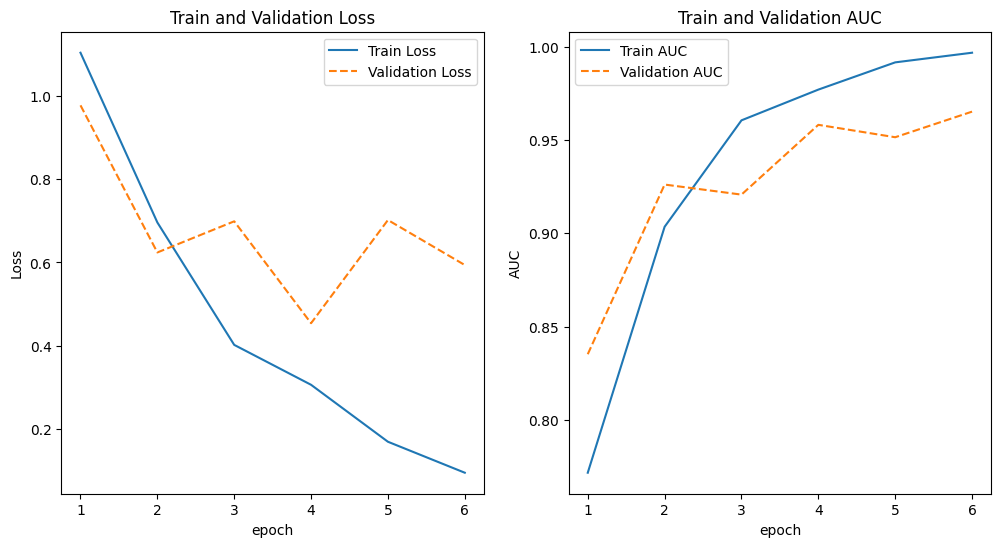

In [139]:
plot_train_val_metrics(epoch_loss_values, val_loss_values, train_auc_values, val_auc_values)

# Evaluarea pe datasetul de testing

Precision on test set: 0.7603
Recall on test set: 0.6954
F1-score on test set: 0.6604
Accuracy on test set: 0.6954


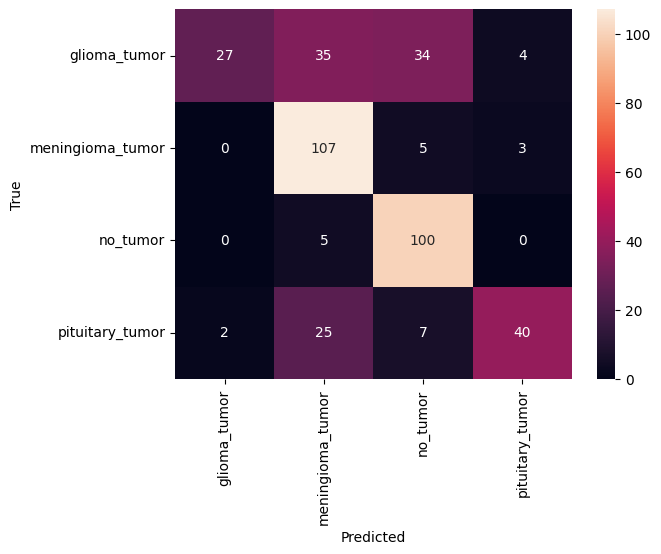

In [140]:
test_evaluation()

# 2.1 Oversampling cu augmentari

In [154]:
def apply_oversampling(dataset):
    from imblearn.over_sampling import RandomOverSampler
    from torchvision import transforms

    # Separate data and labels
    data, labels = zip(*dataset)

    if not isinstance(data, torch.Tensor):
        data = torch.stack([torch.tensor(inp, dtype=torch.float32) for inp in inputs])
    if not isinstance(labels, torch.Tensor):
        labels = torch.tensor(labels, dtype=torch.long)
    inputs, labels = inputs.to(device), labels.to(device)

    data, labels = data.to(device), labels.to(device)


    ros = RandomOverSampler()
    data_resampled, labels_resampled = ros.fit_resample(data.view(len(data), -1).numpy(), labels.numpy())

    # Convert resampled data back to tensors
    data_resampled = torch.tensor(data_resampled, dtype=torch.float32).view(-1, *data.shape[1:])
    labels_resampled = torch.tensor(labels_resampled, dtype=torch.long)

    
    # Define transformations
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1))
    ])
    data_resampled = torch.stack([transform(img) for img in data_resampled])

    # Return as TensorDataset
    oversampled_dataset = TensorDataset(data_resampled, labels_resampled)
    return oversampled_dataset


In [156]:
model, optimizer, loss_function, device = reinitialize_model()
root_directory = "runs"
apply_oversampling(train_dataset)

y_pred_trans = Compose([Activations(softmax=True)])
y_trans = Compose([AsDiscrete(to_onehot=4)])

max_epochs = 6
val_interval = 1
auc_metric = ROCAUCMetric()

best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
val_loss_values = []
metric_values = []
writer = SummaryWriter()

label_to_index = {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}

train_auc_values = []
val_auc_values = []

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    y_pred_train = torch.tensor([], dtype=torch.float32, device=device)
    y_train = torch.tensor([], dtype=torch.long, device=device)

    for (inputs, labels) in train_loader:
        step += 1
        inputs, labels = batch_data
        # labels = [label_to_index[label] for label in labels]

        if not isinstance(inputs, torch.Tensor):
            inputs = torch.stack([torch.tensor(inp, dtype=torch.float32) for inp in inputs])
        if not isinstance(labels, torch.Tensor):
            labels = torch.tensor(labels, dtype=torch.long)
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        # outputs.to(device)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        y_pred_train = torch.cat([y_pred_train, outputs], 0)
        y_train = torch.cat([y_train, labels], 0)

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    y_train_onehot = [y_trans(i) for i in decollate_batch(y_train, detach=False)]
    y_pred_train_act = [y_pred_trans(i) for i in decollate_batch(y_pred_train)]
    auc_metric(y_pred_train_act, y_train_onehot)
    train_auc = auc_metric.aggregate().item()
    auc_metric.reset()
    train_auc_values.append(train_auc)
    print(f"epoch {epoch + 1} training AUC: {train_auc:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        val_loss = 0
        y_pred_val = torch.tensor([], dtype=torch.float32, device=device)
        y_val = torch.tensor([], dtype=torch.long, device=device)
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = val_data
                val_labels = [label_to_index[label] for label in val_labels]

                if not isinstance(val_inputs, torch.Tensor):
                    val_inputs = torch.stack([torch.tensor(inp, dtype=torch.float32) for inp in val_inputs])
                if not isinstance(val_labels, torch.Tensor):
                    val_labels = torch.tensor(val_labels, dtype=torch.long)

                val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
                val_outputs = model(val_inputs)
                val_loss += loss_function(val_outputs, val_labels).item()

                y_pred_val = torch.cat([y_pred_val, val_outputs], 0)
                y_val = torch.cat([y_val, val_labels], 0)

        val_loss /= len(val_loader)
        val_loss_values.append(val_loss)
        print(f"epoch {epoch + 1} validation loss: {val_loss:.4f}")

        y_val_onehot = [y_trans(i) for i in decollate_batch(y_val, detach=False)]
        y_pred_val_act = [y_pred_trans(i) for i in decollate_batch(y_pred_val)]
        auc_metric(y_pred_val_act, y_val_onehot)
        val_auc = auc_metric.aggregate().item()
        auc_metric.reset()
        val_auc_values.append(val_auc)
        print(f"epoch {epoch + 1} validation AUC: {val_auc:.4f}")

        if val_auc > best_metric:
            best_metric = val_auc
            best_metric_epoch = epoch + 1
            torch.save(model.state_dict(), os.path.join(root_dir, "best_metric_model.pth"))
            print("saved new best metric model")

        print(
            f"current epoch: {epoch + 1} current AUC: {val_auc:.4f} "
            f"best AUC: {best_metric:.4f} at epoch: {best_metric_epoch}"
        )



UnboundLocalError: local variable 'inputs' referenced before assignment